# Import Statements (libraries + Functions)

In [169]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [170]:
#import sklearn

In [171]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [172]:
#from Bio import SeqIO

In [173]:
#import io

In [174]:
import json

In [175]:
# import screed
# import mmh3

In [176]:
#import subprocess

In [177]:
#from pycirclize import Circos

In [178]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [179]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [180]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [181]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [182]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [183]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Defining Functions

### Define `DNA-Features-Viewer` Preprocessing Functions

In [184]:

def generate_Event_GraphicFeatures(i_GC_Events_DF):

    L_GFeats = []
    
    for i, row in i_GC_Events_DF.iterrows():
        
        Rv_Start = row["start_0based"]
        Rv_End = row["end_1based"]
        i_Event_ID = row["EventID"]

        Event_Feat = GraphicFeature(start = Rv_Start , end = Rv_End,
                                      label = i_Event_ID[-3:],
                                      linewidth = 0.5,
                                      color = "#CBC3E3", #"purple",
                                      thickness = 5, 
                                      fontdict = {"fontsize": 4},
                                      linecolor = "black")
        
        L_GFeats.append(Event_Feat)

    return L_GFeats


def AddEvents_ToGraphicRecord(Graphic_Record, i_GC_Events_DF):

    L_Event_GFeats = generate_Event_GraphicFeatures(i_GC_Events_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Event_GFeats

    return Graphic_Record


def generate_Epitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]

        Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                      #label = i_epitope_ID,
                                      color = "darkred",
                                      linecolor = "black")
        
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def generate_AssayedEpitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]
        i_PosEpitope = row["PosEpitope_Any"]
        if i_PosEpitope == True:
    
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          linewidth = 0.5,
                                          color = "darkred",
                                          thickness = 5,
                                          linecolor = "black")
            
        else:
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          #linewidth = 0.5,
                                          color = "lightgrey", alpha = 0.3,
                                          thickness = 5,
                                          linewidth = 0.5,
                                          linecolor = "black")

            
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def AddEpitopes_ToGraphicRecord(Graphic_Record, i_Epitopes_DF):

    L_Epitope_GFeats = generate_Epitope_GraphicFeatures(i_Epitopes_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Epitope_GFeats

    return Graphic_Record




## Functions for Composite vizs of results + gene annotations
`H37Rv Gene Annoations` + `Epitope Mapping`, + `mutation frequency` + `GC Events`, `etc`

In [185]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_Anno_Epitope_MutFreq(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (7, 3),
    height_ratios: Tuple[int, int, int, int] = (3, 5, 1, 4),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # 👈 new option
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot genomic annotations, per-codon mutation counts, epitope coverage summary,
    and assayed peptides for a window [Viz_Start, Viz_End].

    Epitope coverage colors are normalized to the global max of Cov_PosEpitopes
    across the entire in_EpitopeCov_DF.
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        4, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax = axs

    # --- Gene Annotations ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            if epi_global_max is None:
                global_max = in_EpitopeCov_DF["Cov_PosEpitopes"].max()
            else:
                global_max = epi_global_max
                
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")

    # --- Assayed peptides ---
    #if hasattr(AllPeptides_Records_cropped, "plot"):
    AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)


    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    AllAssayedPeptides_ax.xaxis.set_major_formatter(formatter)
    AllAssayedPeptides_ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    AllAssayedPeptides_ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))
    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
    }
    return fig, axes


### Functions - composite viz of `epitopes`,`mutation-freq`, and `GC events`

In [186]:
# Define all functions from scratch, then apply them to esxK/L and PPE18 regions.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from pathlib import Path


# ------------------------
# Constants (colors + sizes)
# ------------------------
NT_COLORS = {"A": "green", "T": "red", "C": "blue", "G": "orange"}
EVENT_BAR_COLOR = "#C9A0DC"   # light purple

# ------------------------
# Helper functions
# ------------------------
def _to_int_series(s: pd.Series) -> pd.Series:
    """Convert a Series to Int64 safely (NaNs preserved)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def select_events_overlapping_region(pGCE_df: pd.DataFrame, start1: int, end1: int) -> pd.DataFrame:
    """
    Return events whose intervals intersect [start1, end1] (1-based, inclusive).
    Expects event columns: 'start_0based' and 'end_1based'.
    Adds '__start1__' and '__end1__' (both floats, 1-based) to the result.
    """
    start0 = _to_int_series(pGCE_df["start_0based"])
    end1b  = _to_int_series(pGCE_df["end_1based"])
    s1 = start0 + 1           # convert to 1-based
    e1 = end1b                # already 1-based
    mask = (e1 >= start1) & (s1 <= end1)
    out = pGCE_df.loc[mask].copy()
    out["__start1__"] = s1[mask].astype(float)
    out["__end1__"]   = e1[mask].astype(float)
    return out

def prepare_snps_positions(snps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a '__pos1__' column (1-based position) using Pos_0based or Pos_1based.
    Keeps all other columns intact.
    """
    out = snps_df.copy()
    if "Pos_0based" in out.columns:
        out["__pos1__"] = out["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in out.columns:
        out["__pos1__"] = out["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    return out

def _format_x_plain(ax):
    """Force full integer tick labels (no scientific notation, no offset)."""
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

def _draw_event_rect(ax, y_center: float, x0: float, x1: float, bar_height: float, color: str = EVENT_BAR_COLOR):
    """Draw an event as a filled rectangle centered at y_center with given height."""
    width = max(0.0, x1 - x0)
    rect = Rectangle((x0, y_center - bar_height/2), width, bar_height,
                     facecolor=color, edgecolor='none', alpha=0.9)
    ax.add_patch(rect)

# ------------------------
# Plotting functions
# ------------------------
def plot_multi_event_snp_stack(
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    bar_height: float = 0.5,         # thickness of each event bar
    snp_line_width: float = 0.9, #1.2,     # SNP tick thickness
    label_fontsize: int = 8,
    fig_width: float = 9.0,
    dpi: int = 180,
    title: str | None = None,
    outfile: str | None = None,
):
    """
    Stacked view: one row per overlapping event. Labels are placed slightly ABOVE each event.
    SNP ticks span the same height as the event bar.
    """
    # Choose events & SNPs in the window
    events = select_events_overlapping_region(pGCE_df, region_start1, region_end1)
    if events.empty:
        raise ValueError("No events overlap the requested region.")
    events = events.sort_values(["__start1__", "__end1__"]).reset_index(drop=True)

    snps = prepare_snps_positions(snps_df)
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # Layout
    n = len(events)
    fig_height = max(1.5, 0.38 * n + 1.0)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    y_levels = np.arange(n, dtype=float)[::-1]  # top to bottom

    # Draw
    for idx, (_, ev) in enumerate(events.iterrows()):
        y = y_levels[idx]
        x0 = max(region_start1, float(ev["__start1__"]))
        x1 = min(region_end1,   float(ev["__end1__"]))
        _draw_event_rect(ax, y, x0, x1, bar_height, EVENT_BAR_COLOR)

        # SNPs (same height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, r in s_ev.iterrows():
                xv = float(r["__pos1__"])
                nt = str(r.get("Child_Call", "")).upper()[:1]
                color = NT_COLORS.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # Label above the bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # Cosmetics
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, len(y_levels) - 1 + 0.8)
    ax.set_yticks([])
    ax.set_xlabel("Genomic position (1-based)")
    _format_x_plain(ax)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)

    from matplotlib.lines import Line2D
    legend_elems = [Line2D([0], [0], color=NT_COLORS[k], lw=2, label=k) for k in ["A","T","C","G"] if k in NT_COLORS]
    ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9, loc="upper right")

    if title is None:
        title = f"Events & SNPs in region {region_start1}-{region_end1}"
    ax.set_title(title, fontsize=10)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")
        return fig, ax, outfile
    return fig, ax, None
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_multi_event_snp_packed_on_ax(
    ax,
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    min_gap: int = 0,                 # bp gap required to share a row
    bar_height: float = 0.5,          # thickness of each event bar
    snp_line_width: float = 1.2,      # SNP tick thickness
    label_fontsize: int = 8,
    nt_colors: dict | None = None,    # e.g. {"A":"green","T":"red","C":"blue","G":"orange"}
    event_bar_color: str = "#C9A0DC", # light purple
    hide_spines: tuple[str, ...] = ("left", "top", "right"),
    show_xlabel: bool = True,
    title: str | None = None,
    add_legend: bool = False,
):
    """
    Packed view: non-overlapping events (within [region_start1, region_end1], 1-based)
    share rows to save vertical space. Draws onto the provided Matplotlib Axes `ax`.

    Returns
    -------
    ax, summary
      summary = {"nrows": int, "events_plotted": list[str], "window": (start1, end1)}
    """
    # defaults
    if nt_colors is None:
        nt_colors = {"A":"green", "T":"red", "C":"blue", "G":"orange"}

    # --- Select events that overlap the window (convert to 1-based) ---
    s1 = pd.to_numeric(pGCE_df["start_0based"], errors="coerce").astype("Int64") + 1
    e1 = pd.to_numeric(pGCE_df["end_1based"],   errors="coerce").astype("Int64")
    mask = (e1 >= region_start1) & (s1 <= region_end1)
    events = pGCE_df.loc[mask].copy()
    if events.empty:
        print("No events overlap the requested region.")
        return ax, None
        #raise ValueError("No events overlap the requested region.")
        
    events["__start1__"] = s1[mask].astype(float)
    events["__end1__"]   = e1[mask].astype(float)

    # Clip to window & sort for packing
    events["__clip_start__"] = np.maximum(events["__start1__"].values, region_start1)
    events["__clip_end__"]   = np.minimum(events["__end1__"].values,   region_end1)
    events = events.sort_values(["__clip_start__", "__clip_end__"]).reset_index(drop=True)

    # --- Greedy row packing (no overlaps on the same row) ---
    rows_last_end = []
    row_of_event = []
    for _, ev in events.iterrows():
        placed = False
        s = float(ev["__clip_start__"])
        e = float(ev["__clip_end__"])
        for ri in range(len(rows_last_end)):
            if s > (rows_last_end[ri] + min_gap):
                row_of_event.append(ri)
                rows_last_end[ri] = e
                placed = True
                break
        if not placed:
            row_of_event.append(len(rows_last_end))
            rows_last_end.append(e)
    events["__row__"] = row_of_event

    # --- Prepare SNPs (get 1-based position) ---
    snps = snps_df.copy()
    if "Pos_0based" in snps.columns:
        snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in snps.columns:
        snps["__pos1__"] = snps["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # --- Layout and draw ---
    nrows = int(events["__row__"].max()) + 1
    for _, ev in events.iterrows():
        r = int(ev["__row__"])
        y = (nrows - 1 - r)  # row 0 at top
        x0 = float(ev["__clip_start__"])
        x1 = float(ev["__clip_end__"])

        # event rectangle
        width = max(0.0, x1 - x0)
        rect = Rectangle((x0, y - bar_height/2), width, bar_height,
                         facecolor=event_bar_color, edgecolor='none', alpha=0.9)
        ax.add_patch(rect)

        # SNP ticks (span full bar height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, rS in s_ev.iterrows():
                xv = float(rS["__pos1__"])
                nt = str(rS.get("Child_Call", "")).upper()[:1]
                color = nt_colors.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # label above bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # --- Cosmetics ---
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, nrows - 1 + 0.8)
    ax.set_yticks([])
    if show_xlabel:
        ax.set_xlabel("Genomic position (1-based)")

    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)
    for spine in hide_spines:
        ax.spines[spine].set_visible(False)

    if add_legend:
        legend_elems = [Line2D([0], [0], color=nt_colors[k], lw=2, label=k)
                        for k in ["A","T","C","G"] if k in nt_colors]
        ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9,
                  loc="upper right")

    if title is not None:
        ax.set_title(title, fontsize=10)

    summary = {
        "nrows": int(nrows),
        "events_plotted": events["EventID"].tolist(),
        "window": (region_start1, region_end1),
    }
    return ax, summary


In [187]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_mut_epitope_region_with_gce_V2(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    pGCE_df,          
    snps_df,
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (5, 5),
    height_ratios: Tuple[int, int, int, int, int] = (4, 5, 1, 4, 8),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # if None, uses global max from in_EpitopeCov_DF
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Same as plot_mut_epitope_region, but adds a GC events track at the bottom.

    Axes order (top→bottom):
      0: Genome_Anno_ax (gene annotations)
      1: MF_ax          (mutation counts)
      2: EpiSumm_ax     (epitope density summary bar)
      3: AllAssayedPeptides_ax (all assayed peptides)
      4: GCE_ax         (gene conversion events)
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped   = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        5, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax, GCE_ax = axs

    # --- Gene Annotations (top track) ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold = genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary (global-normalized) ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            global_max = (in_EpitopeCov_DF["Cov_PosEpitopes"].max()
                          if epi_global_max is None else float(epi_global_max))
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")


    # --- Assayed peptides ---
    if hasattr(AllPeptides_Records_cropped, "plot"):
        AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)
    AllAssayedPeptides_ax.set_xticks([])

    
    # --- GC events (bottom track) ---
    
    
    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1 = Viz_Start, region_end1 = Viz_End,
                                      pGCE_df = pGCE_DF, snps_df = snps_df, label_fontsize = 4,
                                      add_legend=False, )

    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1=Viz_Start, region_end1=Viz_End,
                                      pGCE_df = pGCE_df,
                                      snps_df = snps_df,
                                      min_gap=gce_min_gap,
                                      bar_height=gce_bar_height,
                                      snp_line_width=gce_snp_line_width,
                                      label_fontsize=gce_label_fontsize,
                                      #show_xlabel=show_xlabel_on_gce,
                                      add_legend=False,
                                      title=None,)



    if show_bottom_xticks:
        GCE_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        GCE_ax.ticklabel_format(style='plain', axis='x')
        GCE_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))




    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
        "GCE_ax": GCE_ax,
    }
    return fig, axes


### Define function for ploting Anno + GCEs in a region

In [188]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt

def plot_Anno_with_GCE(
    Viz_Start: int,
    Viz_End: int,
    in_Genome_Graphic_Record,   # dna_features_viewer GraphicRecord (H37Rv)
    pGCE_df,                    # GC events dataframe
    snps_df,                    # SNPs dataframe (Pos_0based or Pos_1based, EventID, Child_Call)
    *,
    figsize: Tuple[float, float] = (5, 5), 
    dpi: int = 180,                            
    height_ratios: Tuple[float, float] = (1.0, 2.5),
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_xlabel_on_gce: bool = True,
    title: Optional[str] = None,
    tight_layout: bool = True,
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot gene annotations (top) and packed GC events with SNPs (bottom).
    Returns (fig, {'Genome_Anno_ax':..., 'GCE_ax':...}).
    """
    # Crop genome record to region
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        2, 1, figsize=figsize, dpi=dpi,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, GCE_ax = axs

    # Top: gene annotations
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(
            strand_in_label_threshold=genome_label_threshold, ax=Genome_Anno_ax
        )
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")

    # Bottom: packed GC events + SNPs (uses your on-axis helper)
    plot_multi_event_snp_packed_on_ax(
        GCE_ax,
        region_start1=Viz_Start, region_end1=Viz_End,
        pGCE_df=pGCE_df, snps_df=snps_df,
        min_gap=gce_min_gap,
        bar_height=gce_bar_height,
        snp_line_width=gce_snp_line_width,
        label_fontsize=gce_label_fontsize,
        show_xlabel=show_xlabel_on_gce,
        add_legend=False,
        title=None
    )

    if title:
        fig.suptitle(title, fontsize=11)

    if tight_layout:
        fig.tight_layout()

    return fig, {"Genome_Anno_ax": Genome_Anno_ax, "GCE_ax": GCE_ax}


# Parse `Mtb151CI` Isolate Metadata

In [189]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [190]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [191]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [192]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [193]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [194]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [195]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [196]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [197]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [198]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [199]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 15)

In [200]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [201]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

In [202]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


#### Peak at head of each HmMap Regions DFs

In [203]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [204]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [205]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [206]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [207]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [208]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [209]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [210]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [211]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [212]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [213]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [214]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [215]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 
Lind16_Peptides_HLAInfo_TSV = f"{Repo_Epitope_MainDir}/240815.Lindestram2016.HLA_ResponseInfo.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [216]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [217]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF["Reactivity"] = LPM_AllPep_V2_DF["PosEpitope_Any"].replace(True, "Positive").replace(False, "Negative")
LPM_AllPep_V2_DF.shape

(18741, 31)

In [218]:
LPM_AllPep_V2_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity'], dtype='object')

### Create a Dict that maps each epitope sequence to all gene's that contain the sequence

In [219]:
# Group by 'Epitope_Seq' and aggregate the unique 'Symbol' values into a string
EpiSeq_to_Symbols_dict = (
    LPM_AllPep_V2_DF.groupby('Epitope_Seq')['Symbol']
    .apply(lambda x: ', '.join(x.unique()))
    .to_dict()
)    

In [220]:
EpiSeq_to_Symbols_dict["DLYSKIESLPASQRD"]

'icd2'

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [221]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [222]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 31)

In [223]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 31)

In [224]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 31)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [225]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [226]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


### `Lind-16` - parse and process HLA and epitope positivity info in 63 ZA individuals

In [227]:
Lind16_IEDB_AllPeptides_HLAInfo_DF = pd.read_csv(Lind16_Peptides_HLAInfo_TSV, sep = "\t")

Lind16_IEDB_AllPeptides_HLAInfo_DF["Gene(s)"] = Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_IEDB_PosEpitopes_HLAInfo_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Status == 'Positive' ")


# Group by "Epitope_Seq" and sum the relevant numeric columns
Lind16_EpiPosFreq_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.groupby("Epitope_Seq")["Num_Positive"].sum()
Lind16_EpiPosFreq_DF = Lind16_EpiPosFreq_DF.reset_index()

Lind16_EpiPosFreq_DF["Num_Assayed"] = 63

# Assuming Num_Assayed is 63 for each epitope, calculate the fraction of individuals positive for each epitope
Lind16_EpiPosFreq_DF['Fraction_Positive'] = Lind16_EpiPosFreq_DF['Num_Positive'] / 63

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Gene(s)"].fillna("")


In [228]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.head(3)

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
0,DAHGAMIRAQAGSLE,Positive,HLA-DQB1*06:02,5,5,1.0,"esxI, esxV"
1,ISTNIRQAGVQYSRA,Positive,HLA-DQB1*06:02,4,4,1.0,esxB
2,MHVSFVMAYPEMLAA,Positive,HLA-DQB1*06:02,4,4,1.0,NaN


In [229]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.shape

(1025, 7)

In [230]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF.shape

(499, 7)

In [231]:
Lind16_EpiPosFreq_DF["Epitope_Seq"].nunique()

761

In [232]:
Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].nunique()

761

In [233]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF["Epitope_Seq"].nunique()

235

# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [234]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [235]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [236]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [237]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [238]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

#### How much oftthe genome is an epitope genome-wide (HHR + Unique)

In [239]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

#### How much of genome is an epitope in an HHR?

In [240]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length_WiPosEpitope"].sum()


4395

#### How much of genome is an HHR?

In [241]:
Rv_HHR_DF["Length"].sum()

256568

In [242]:
4411532

4411532

#### How much of genome is an HHR-antigen?

In [243]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length"].sum()

14304

In [244]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["Length"].sum()

34170

In [245]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["Length"].sum()

326052

In [246]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

In [247]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [248]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

In [249]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


### c) Parse Per Genome Position  Epitope mapping coverage DF

In [250]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [251]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [252]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [253]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 51)

In [254]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [255]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 51)

In [256]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [257]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,False,0,0,0,.


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [258]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 24)

In [259]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,False,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,False,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,True,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,False,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [260]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [261]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [262]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [263]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [264]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


### Create DNA-Features-Viewer Objects for results (`Epitope Mapping`, `Mutations`, `GC Events`)

In [265]:
LPM_AllPep_V2_DF

LPM_NegPep_V2_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
0,UnqPeptide_1,FPTLNYAVSVAEACE,15,Rv0322,udgA,368,383,NC_000962.3,390363,390408,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_1-udgA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
1,UnqPeptide_2,ERIPKFAHLPTVLGE,15,Rv2992c,gltS,238,253,NC_000962.3,3349518,3349563,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_2-gltS,0,False,False,2,0,False,0,False,0,.,0,.,Negative
2,UnqPeptide_3,FPGVLVAARPVGMFR,15,Rv3628,ppa,66,81,NC_000962.3,4067620,4067665,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_3-ppa,0,False,False,0,0,False,0,False,0,.,0,.,Negative
3,UnqPeptide_4,GDPARTMRRMIGGLR,15,Rv3617,ephA,167,182,NC_000962.3,4058233,4058278,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_4-ephA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
4,UnqPeptide_5,LLPYSYDDLDFNALL,15,Rv1282c,oppC,40,55,NC_000962.3,1435978,1436023,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_5-oppC,0,False,False,0,0,False,0,False,0,.,0,.,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18736,UnqPeptide_18729,GRVVVNDDVVRGLRI,15,Rv2030c,Rv2030c,89,104,NC_000962.3,2278174,2278219,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18729-Rv2030c,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18737,UnqPeptide_18730,FAAEKATPEMVAFMV,15,Rv1415,ribA2,35,50,NC_000962.3,1590501,1590546,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18730-ribA2,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18738,UnqPeptide_18731,CRVILLDAAPAVLPP,15,Rv0392c,ndhA,208,223,NC_000962.3,471970,472015,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18731-ndhA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18739,UnqPeptide_18732,LRNIGVFGVNLVGLS,15,Rv2047c,Rv2047c,430,445,NC_000962.3,2293191,2293236,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18732-Rv2047c,0,False,False,0,0,False,0,False,0,.,0,.,Negative


#### All assayed peptides + positive epitopes

In [266]:
LPM_AllPeptides_GraphicFeatures = generate_AssayedEpitope_GraphicFeatures(LPM_AllPep_V2_DF)

LPM_AllPeptides_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_AllPeptides_GraphicFeatures)



LPM_PosEpitopes_GraphicFeatures = generate_AssayedEpitope_GraphicFeatures(LPM_PosEpi_V2_DF)
                                                 
LPM_PosEpitopes_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_PosEpitopes_GraphicFeatures)


#### DNA-Features viewer objects for all putative GC events

In [267]:
pGC_Events_GraphicFeatures = generate_Event_GraphicFeatures(pGCE_DF)

pGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = pGC_Events_GraphicFeatures)


In [268]:
len(pGC_Events_GraphicFeatures)

324

#### DNA-Features viewer objects for all mapped GC events

In [269]:
mGC_Events_GraphicFeatures = generate_Event_GraphicFeatures(mGCE_DF)

mGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = mGC_Events_GraphicFeatures)


In [270]:
len(mGC_Events_GraphicFeatures)

213

# Part 2: Reanalysis of GENOME-wide mutation burden of antigens

In [271]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

#### How many total antigens are detected? (`53 total, 20 in HHR, 33 in Non-HHR`)

In [272]:
Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True").shape

(53, 36)

## Plot normalized mutational burden between protein categories
(`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [273]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


#### Code to create plot

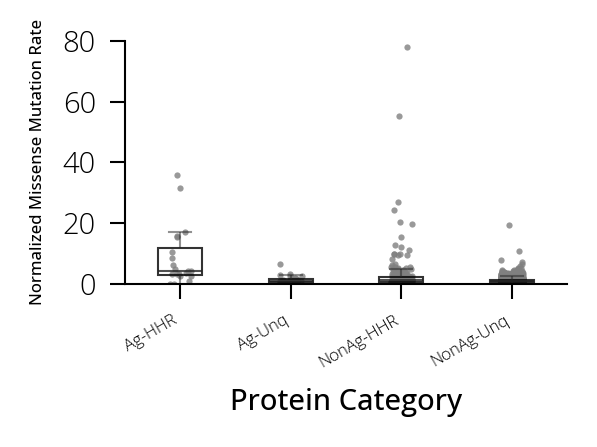

In [274]:
GWMutR_fig, GWMutR_ax = plt.subplots(figsize=(2, 1.5))

in_GeneInfo_DF = Genes_GCandMutFreqStats_DF
X_Order = ['Antigen-HHR', 'Antigen-Unq',  'NonReactive-HHR', 'NonReactive-Unq',  ]

# 2) Strip
sns.stripplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF, color = "grey",
    zorder=0, s=1.5, alpha=0.8,
    ax = GWMutR_ax,
)

# 3) Box
sns.boxplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF,
    width=0.4, showcaps=True, fliersize=0,
    linewidth=0.5,
    boxprops={'facecolor':'none','edgecolor':'black','alpha':0.8},
    whiskerprops={'linewidth':0.5,'alpha':0.5},
    capprops={'linewidth':0.5,'alpha':0.5},
    medianprops={'linewidth':0.5,'alpha':0.8},
    ax = GWMutR_ax,
)

GWMutR_ax.set_ylim(0, 80)
GWMutR_ax.set_xlabel("Protein Category")
GWMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)


# Replace long x-axis labels with shorter ones
short_labels = [ 'Ag-HHR', 'Ag-Unq', 'NonAg-HHR', 'NonAg-Unq',]
GWMutR_ax.set_xticks(range(len(X_Order)))
GWMutR_ax.set_xticks(ticks=range(len(X_Order)), labels=short_labels, fontsize=4, rotation=30, ha='right')

sns.despine()

plt.show()

#### Show plot 

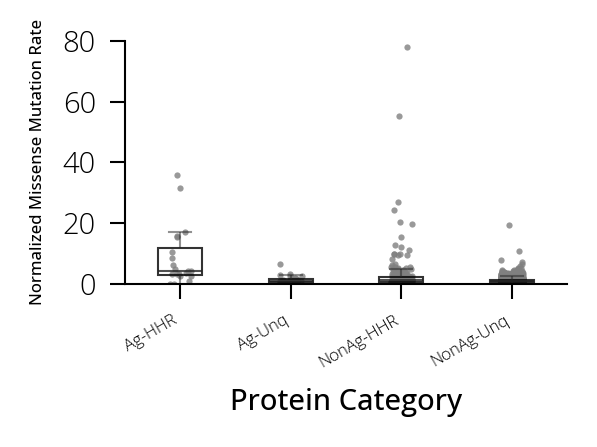

In [275]:

GWMutR_fig

## Statistical Comparison of mutational burden (Genome-wide, 4 categories)


#### Look at distribution stats for each group (`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [276]:
MutationBurdenPerGene_GroupStats_DF = Genes_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe().reset_index()

In [277]:
MutationBurdenPerGene_GroupStats_DF

,AntigenLVL2_And_HHR_Comb,count,mean,std,min,25%,50%,75%,max
0,Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
1,Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
2,NonReactive-HHR,204.0,3.005899,7.481313,0.0,0.598638,1.332993,2.317748,78.102190
3,NonReactive-Unq,3584.0,0.889619,0.813826,0.0,0.385914,0.763359,1.231527,19.251337


# Part 3: Focused mutational burden analysis of `HHR vs Non-HHR antigens`

## A) Compare OVERALL mutation burden between HHR and non-HHR antigens

The median mutational burden of HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA. <br>
The median mutational burden of Non-HHR antigens is 1 missense mutations (IQR: 0-2) per 100 AA. <br>
The mutational burden of HHR antigens is significantly higher than non-HHR antigens. <br>


In [278]:
Antigen_GCandMutFreqStats_DF.groupby("HasHmRegion")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
HasHmRegion,,,,,,,,
False,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
True,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802


In [279]:
Antigen_NonHHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False")["RelFreq_NS_Muts"]
Antigen_HHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True")["RelFreq_NS_Muts"]


In [280]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(Antigen_NonHHR_RelFreq, Antigen_HHR_RelFreq)
# Output the result
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}") 

Wilcoxon rank-sum test statistic: -4.367156268334564
P-value: 1.2587467092606682e-05


In [281]:
### The median mutational burden on HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA .
### This is significantly higher than the mutational burden on non-HHR antigens, with a median of 1 missense mutations (IQR: 0-2) per 100 AA


In [282]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut != Has_mGCE_WiNSMut")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
10,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.5,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,18.0,4.137931,0.0,False,False,False,True,True,True,135,0.103448


In [283]:
Antigen_GCandMutFreqStats_DF.query("Total_NS_Muts_BymGCE != Total_NS_Muts_BypGCE").shape

(4, 38)

In [284]:
Antigen_GCandMutFreqStats_DF.head(1)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.25,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594


In [285]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 38)

In [286]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 38)

## B) Plot normalized mutation rate of PR vs non-PR antigens

#### Code to create plot

In [287]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


Seed: 134


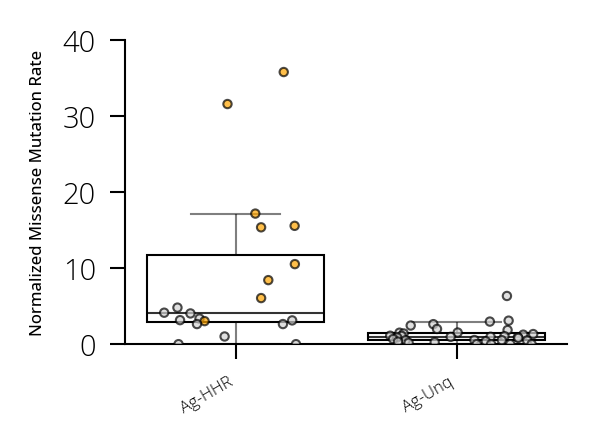

In [288]:
# Create figure and axis
AMutR_fig, AMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 134
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
               order = X_Order, hue = "Has_mGCE_WiNSMut", palette = Has_GC_EpiMut_Pallete,
               jitter = 0.35,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.7, size = 2,
               edgecolor="black", linewidth=0.5, ax = AMutR_ax,
               legend=False, )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = AMutR_ax,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
AMutR_ax.set_ylim(0, 40)
AMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)
AMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-HHR', 'Ag-Unq']
AMutR_ax.set_xticks(range(len(X_Order)))
AMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=30, ha='right')

sns.despine(ax=AMutR_ax)

plt.tight_layout()

plt.show()



#### Show plot 

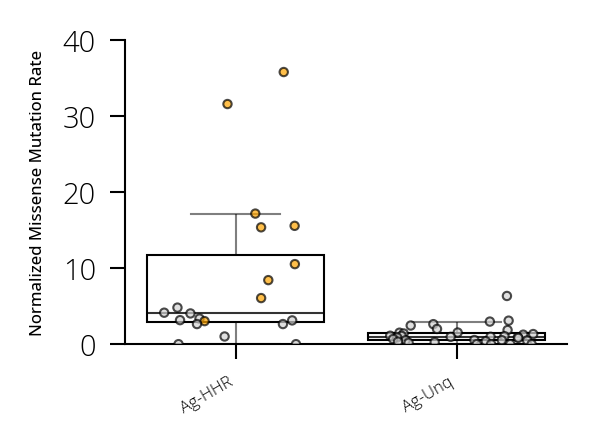

In [289]:

AMutR_fig

### What are the top 10 antigens with the highest OVERALL mutational burden?

In [290]:
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "N_Pos", "Total", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",   ]
# "Length", "H37rv_GeneID",
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",  "Total_NS_Muts_BypGCE",  ]

i_TarCols_V2 = [ "Symbol", "Length", "HasHmRegion", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", ]

Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,PPE60,1182,True,35.786802,6.091371,141.0,24.0
1,esxL,285,True,31.578947,28.421053,30.0,27.0
2,esxP,297,True,17.171717,2.020202,17.0,2.0
3,PPE18,1176,True,15.561224,11.224490,61.0,44.0
4,PPE19,1191,True,15.365239,2.267003,61.0,9.0
5,esxO,285,True,10.526316,3.157895,10.0,3.0
6,esxN,285,True,8.421053,1.052632,8.0,1.0
7,Rv0010c,426,False,6.338028,1.408451,9.0,2.0
8,esxK,297,True,6.060606,3.030303,6.0,3.0
9,Rv3115,1248,True,4.807692,0.240385,20.0,1.0


In [291]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


In [292]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(20)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


### Create table of top 5 HHR and Non-HHR antigens (Ranked by mut-burden in each group)

In [293]:
i_TarCols_V3 = ["HasHmRegion", "Symbol", "Length", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "pGCE_Ovrlap", "mGCE_Ovrlap",]

Top5_HHR_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)

Top5_UNQ_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)


Top5HHR_Vs_Top5Unq_Antigens_Stats_DF = pd.concat([Top5_HHR_Antigen_GCandMutFreqStats_DF, Top5_UNQ_Antigen_GCandMutFreqStats_DF],
                                                 axis =0 )
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF.shape

(10, 9)

In [294]:
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
0,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
1,False,esxH,291,3.092784,3.092784,3.0,3.0,0,0
2,False,esxB,303,2.970297,2.970297,3.0,3.0,0,0
3,False,Rv2660c,228,2.631579,1.315789,2.0,1.0,0,0
4,False,rimJ,612,2.450980,0.490196,5.0,1.0,0,0


### Create table of top 10 antigens (Ranked by mut-burden)

In [295]:
Top10MutBurden_Antigen_Stats_DF = Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V3].reset_index(drop=True)
Top10MutBurden_Antigen_Stats_DF.shape

(10, 9)

In [296]:
Top10MutBurden_Antigen_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
5,True,esxO,285,10.526316,3.157895,10.0,3.0,5,5
6,True,esxN,285,8.421053,1.052632,8.0,1.0,3,3
7,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
8,True,esxK,297,6.060606,3.030303,6.0,3.0,5,3
9,True,Rv3115,1248,4.807692,0.240385,20.0,1.0,0,0


# Part 3: Analysis of GC events mutating MHC-II antigens & epitopes

## Basic questions to ask of GC events mutating epitopes/antigens

In [297]:
mGCE_DF.shape

(213, 51)

In [298]:
pGCE_DF.shape

(324, 51)

In [299]:
#mGCE_DF.columns

In [300]:
#mGCE_DF["N_EpiMutated_By_GCE"].value_counts()

In [301]:
#pGCE_DF["N_EpiMutated_By_GCE"].value_counts()

### 1) How many pGC events cause any AA change? (183/324, 86%)

In [302]:
pGCE_DF.shape

(324, 51)

In [303]:
pGCE_WiNSMut_DF = pGCE_DF.query("N_NS_Mut > 0")
pGCE_WiNSMut_DF.shape

(280, 51)

In [304]:
pGCE_WiNSMut_DF.shape[0] / pGCE_DF.shape[0]

0.8641975308641975

### 2) How many pGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (42/324, 13%)

In [305]:
pGCE_InAntigen_DF = pGCE_DF.query("(Overlap_WiAntigenLVL2Gene == True) ")
pGCE_InAntigen_DF.shape

(48, 51)

In [306]:
44/324


0.13580246913580246

In [307]:
pGCE_WiNSMut_InAntigen_DF = pGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
pGCE_WiNSMut_InAntigen_DF.shape

(42, 51)

In [308]:
pGCE_DF.shape

(324, 51)

In [309]:
42/324

0.12962962962962962

In [310]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

In [311]:
# How many unique HHRs? 7
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP
# PPE46
# esxM, esxN

# How many unique proteins? 10 (PPE18, PPE19, PPE60, esxK, esxL, esxO, esxP, esxM, esxN, PPE46)

### 3) How many pGC events mutate (AA change) an epitope (In L2 Antigen)? (25/324, 10%)

In [312]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF = pGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [313]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(25, 51)

In [314]:
pGCE_DF.shape

(324, 51)

In [315]:
25/324

0.07716049382716049

In [316]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
esxL                 5
PPE60                5
esxK,esxL            3
PPE18,esxK,esxL      1
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

# Part 4: Create PPE18 summary DF of epitope coverage and mutation frequency across the entire protein sequence

In [317]:

# Function to compute 0-based genomic position for the first nucleotide of each codon (in coding direction)
def codon_to_pos0(start0, end0, codon_idx_1based, strand_sign):
    k = int(codon_idx_1based)
    if strand_sign == "+":
        # first nt of codon k
        return start0 + (k - 1) * 3
    else:
        # first nt (in coding direction) of codon k on minus strand
        return (end0 - 1) - (k - 1) * 3

### Create first DF w/ all PPE18 Codon Positions

In [318]:
# --- 1) Get PPE18 metadata (coordinates & length) ---
ppe18_Row_DF = Antigen_GCandMutFreqStats_DF.query("Symbol == 'PPE18'").copy()

if ppe18_Row_DF.empty:
    raise ValueError("Couldn't find PPE18 in the antigen stats table.")
    
ppe18_row = ppe18_Row_DF.iloc[0]

chrom = ppe18_row["Chrom"]
PPE18_start = int(ppe18_row["Start"])
PPE18_end   = int(ppe18_row["End"])
PPE18_strand = ppe18_row["Strand"]
length_DNA = int(ppe18_row["Length"])
length_aa = int(391) #int(length_DNA / 3) #ppe18_AA_length

In [319]:
PPE18_RvPerCodon_NSMutFreq_DF = RvPerCodon_NSMutFreq_DF.query("Symbol == 'PPE18'")
PPE18_RvPerCodon_NSMutFreq_DF.shape

(39, 4)

In [320]:
PPE18_RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
839,PPE18,30.0,4,1339435


## Create DF of PPE18 Epitope And Mutation Frequency Stats per Codon

In [321]:
ppe18_AA_length = 392

# Build coverage DataFrame
PPE18_StatsPerPos_DF = pd.DataFrame({
    "Symbol": "PPE18",
    "Codon": range(1, ppe18_AA_length + 1),
})

PPE18_StatsPerPos_DF["RvCoord_Start_0idx"] = PPE18_StatsPerPos_DF["Codon"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))
PPE18_StatsPerPos_DF["RvCoord_Start_1idx"] = PPE18_StatsPerPos_DF["RvCoord_Start_0idx"] + 1

PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF.merge(Rv_EpitopeCov_NonZero_DF[["start", "Cov_PosEpitopes", "Cov_AssayedPeptides"]], 
                                                      left_on = "RvCoord_Start_0idx", 
                                                      right_on = "start",
                                                      how = "left")


PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF.merge(PPE18_RvPerCodon_NSMutFreq_DF[["Codon", "Mutation_Count"]], on = "Codon", how = "left")

PPE18_StatsPerPos_DF["Cov_PosEpitopes"]     = PPE18_StatsPerPos_DF["Cov_PosEpitopes"].fillna(0)
PPE18_StatsPerPos_DF["Cov_AssayedPeptides"] = PPE18_StatsPerPos_DF["Cov_AssayedPeptides"].fillna(0)


PPE18_StatsPerPos_DF["Mutation_Count"] = PPE18_StatsPerPos_DF["Mutation_Count"].fillna(0)
PPE18_StatsPerPos_DF["NS_MutEvent_Freq"] = PPE18_StatsPerPos_DF["Mutation_Count"]


PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF[["Symbol", "Codon", "Cov_PosEpitopes", "Cov_AssayedPeptides", "NS_MutEvent_Freq",
                                             "RvCoord_Start_0idx", "RvCoord_Start_1idx"]]

PPE18_StatsPerPos_DF["AssayedPos_EpitopeMapping"] = PPE18_StatsPerPos_DF["Cov_AssayedPeptides"] > 0

PPE18_StatsPerPos_DF["OvrlapWiEpitope"] = PPE18_StatsPerPos_DF["Cov_PosEpitopes"] > 0

PPE18_StatsPerPos_DF["OvrlapWiEpitope_int"] = (PPE18_StatsPerPos_DF["Cov_PosEpitopes"] > 0).astype(int)


PPE18_StatsPerPos_DF.shape

(392, 10)

In [322]:
PPE18_StatsPerPos_DF.to_csv("PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv", sep ="\t", index=False)
!wc -l PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv

393 PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv


In [323]:
PPE18_StatsPerPos_DF.shape

(392, 10)

In [324]:
PPE18_StatsPerPos_DF.head()

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1
1,PPE18,2,1.0,1.0,0.0,1339351,1339352,True,True,1
2,PPE18,3,1.0,1.0,0.0,1339354,1339355,True,True,1
3,PPE18,4,1.0,1.0,0.0,1339357,1339358,True,True,1
4,PPE18,5,1.0,1.0,0.0,1339360,1339361,True,True,1


In [325]:
PPE18_StatsPerPos_DF["AssayedPos_EpitopeMapping"].value_counts()

AssayedPos_EpitopeMapping
True     391
False      1
Name: count, dtype: int64

In [326]:
PPE18_StatsPerPos_DF["OvrlapWiEpitope"].value_counts()

OvrlapWiEpitope
True     235
False    157
Name: count, dtype: int64

In [327]:
PPE18_StatsPerPos_DF.groupby("OvrlapWiEpitope")["NS_MutEvent_Freq"].describe()

,count,mean,std,min,25%,50%,75%,max
OvrlapWiEpitope,,,,,,,,
False,157.0,0.108280,0.432340,0.0,0.0,0.0,0.0,3.0
True,235.0,0.187234,0.576468,0.0,0.0,0.0,0.0,4.0


In [328]:
PPE18_StatsPerPos_DF.groupby("OvrlapWiEpitope")["NS_MutEvent_Freq"].sum()

OvrlapWiEpitope
False    17.0
True     44.0
Name: NS_MutEvent_Freq, dtype: float64

# Begin Analysis

In [329]:
Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [330]:
Rv_EpitopeCov_NonZero_DF.head()

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1
2,NC_000962.3,539,540,0,1
3,NC_000962.3,540,541,0,1
4,NC_000962.3,541,542,0,1


In [331]:
RvPerCodon_NSMutFreq_DF.shape

(12132, 4)

In [332]:
RvPerCodon_NSMutFreq_DF.head()

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374
1,35kd_ag,252.0,1,3057308
2,35kd_ag,270.0,1,3057255
3,PE1,122.0,1,178945
4,PE1,123.0,1,178940


In [333]:
PPE18_StatsPerPos_DF.head(10)

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1
1,PPE18,2,1.0,1.0,0.0,1339351,1339352,True,True,1
2,PPE18,3,1.0,1.0,0.0,1339354,1339355,True,True,1
3,PPE18,4,1.0,1.0,0.0,1339357,1339358,True,True,1
4,PPE18,5,1.0,1.0,0.0,1339360,1339361,True,True,1
5,PPE18,6,2.0,2.0,0.0,1339363,1339364,True,True,1
6,PPE18,7,2.0,2.0,0.0,1339366,1339367,True,True,1
7,PPE18,8,2.0,2.0,0.0,1339369,1339370,True,True,1
8,PPE18,9,2.0,2.0,0.0,1339372,1339373,True,True,1
9,PPE18,10,2.0,2.0,0.0,1339375,1339376,True,True,1


# Part 1: 

In [334]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

def _subset_window(df, x_col: str, x_min, x_max):
    if x_min is None and x_max is None:
        return df
    if x_min is None:
        return df.loc[df[x_col] <= x_max]
    if x_max is None:
        return df.loc[df[x_col] >= x_min]
    return df.loc[(df[x_col] >= x_min) & (df[x_col] <= x_max)]

def _format_genomic_xaxis(ax, nbins: int = 6):
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style="plain", axis="x", useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=nbins, integer=True))
import numpy as np

def plot_mutfreq_per_codon(
    ax,
    per_codon_df,
    *,
    x_col: str = "RvCoord_Start_0idx",
    y_col: str = "NS_MutEvent_Freq",
    x_min=None,
    x_max=None,
    ylim=None,
    # match your older style
    vline_lw: float = 0.9,
    point_size: float = 2.0,
    alpha_vlines: float = 0.6,
    alpha_points: float = 1.0,
    # new: control whether to drop zeros
    drop_zeros: bool = True,
    zero_eps: float = 0.0,  # set to e.g. 1e-12 if your floats have tiny noise
):
    req = {x_col, y_col}
    missing = req - set(per_codon_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    dfw = _subset_window(per_codon_df, x_col, x_min, x_max).copy()
    if dfw.empty:
        ax.set_ylabel("Mutation freq\n(per codon)")
        return ax

    # Remove zeros (and NaNs) to match the older plotting behavior
    dfw = dfw.loc[dfw[y_col].notna()].copy()
    if drop_zeros:
        dfw = dfw.loc[dfw[y_col] > zero_eps].copy()

    # If everything is zero in this window, keep axis sane but draw nothing
    if dfw.empty:
        # still enforce xlim if requested
        if x_min is not None or x_max is not None:
            ax.set_xlim(
                x_min if x_min is not None else per_codon_df[x_col].min(),
                x_max if x_max is not None else per_codon_df[x_col].max(),
            )
        ax.set_ylim(bottom=0)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_ylabel("Mutation freq\n(per codon)")
        _format_genomic_xaxis(ax)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        return ax

    x = dfw[x_col].to_numpy()
    y = dfw[y_col].to_numpy()

    # Match your older colors
    ax.vlines(x=x, ymin=0, ymax=y, color="black", linewidth=vline_lw, alpha=alpha_vlines)
    ax.scatter(x=x, y=y, color="red", s=point_size, alpha=alpha_points)

    if x_min is not None or x_max is not None:
        ax.set_xlim(
            x_min if x_min is not None else np.nanmin(x),
            x_max if x_max is not None else np.nanmax(x),
        )

    ax.set_ylim(bottom=0)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_ylabel("Mutation freq\n(per codon)")
    _format_genomic_xaxis(ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

def plot_epitope_coverage_diverging_bars(
    ax,
    per_codon_df,
    *,
    x_col="RvCoord_Start_0idx",
    assayed_col="Cov_AssayedPeptides",
    positive_col="Cov_PosEpitopes",
    x_min=None,
    x_max=None,
    # NEW: colors
    positive_color="red",
    assayed_color="grey",
    alpha_assayed=0.35,
    alpha_positive=0.85,
    linewidth=0.0,
    legend=True,
):
    req = {x_col, assayed_col, positive_col}
    missing = req - set(per_codon_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    dfw = _subset_window(per_codon_df, x_col, x_min, x_max).copy()

    # Only plot positions where either track is non-zero
    dfw = dfw.loc[(dfw[assayed_col] > 0) | (dfw[positive_col] > 0)].copy()
    if dfw.empty:
        ax.set_ylabel("Coverage")
        return ax

    x = dfw[x_col].to_numpy()
    assayed = dfw[assayed_col].to_numpy()
    positive = dfw[positive_col].to_numpy()

    # Infer bar width from coordinate spacing
    if len(x) >= 2:
        dx = np.median(np.diff(np.sort(x)))
        width = max(1.0, float(dx))
    else:
        width = 1.0

    ax.axhline(0, linewidth=0.8, color="black")

    # Positive up (red), Assayed down (grey)
    ax.bar(
        x,
        positive,
        width=width,
        align="center",
        color=positive_color,
        alpha=alpha_positive,
        linewidth=linewidth,
        label="Positive epitopes",
    )
    ax.bar(
        x,
        -assayed,
        width=width,
        align="center",
        color=assayed_color,
        alpha=alpha_assayed,
        linewidth=linewidth,
        label="Assayed peptides",
    )

    # Y limits
    pos_max = float(np.nanmax(positive)) if len(positive) else 0.0
    neg_max = float(np.nanmax(assayed)) if len(assayed) else 0.0
    ax.set_ylim(
        -(neg_max * 1.05 if neg_max > 0 else 1.0),
        (pos_max * 1.05 if pos_max > 0 else 1.0),
    )

    if x_min is not None or x_max is not None:
        ax.set_xlim(
            x_min if x_min is not None else np.nanmin(x),
            x_max if x_max is not None else np.nanmax(x),
        )

    ax.set_ylabel("Coverage\n(+pos / −assayed)")
    ax.set_xlabel("Genomic position (0-based)")
    _format_genomic_xaxis(ax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if legend:
        ax.legend(frameon=False, loc="upper right")

    return ax

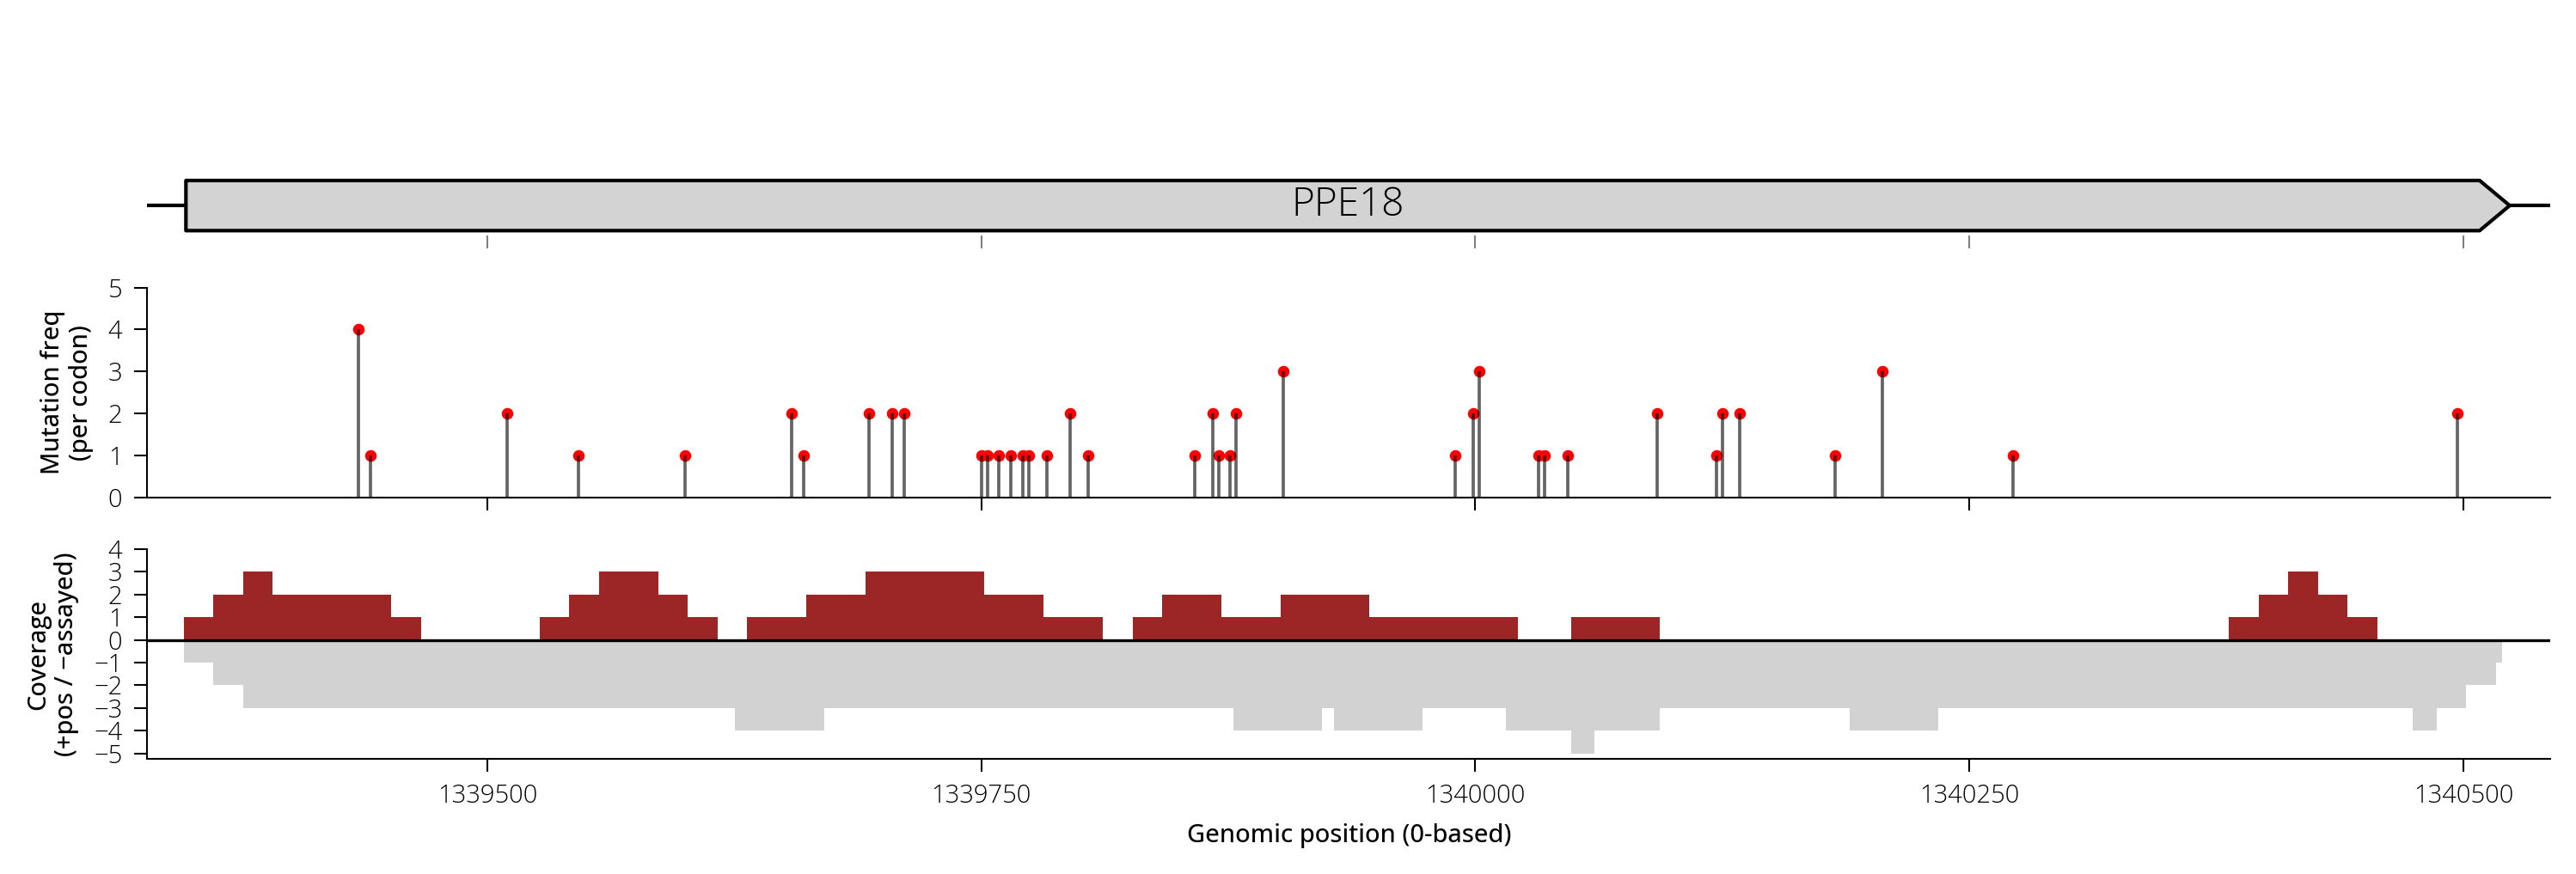

In [335]:

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

i_Symbol_List = ["PPE18"]

i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
i_Gene_End = i_Gene_MutInfo_DF["End"].max()
Viz_Start = i_Gene_Start - 20
Viz_End = i_Gene_End + 20


# ---- Make the requested plots ----
df_plot = PPE18_StatsPerPos_DF



# Figure 1: mutfreq + diverging bars
fig1, axs = plt.subplots(
    3, 1, figsize=(10, 3.4),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 3, 3]}
)
Genome_Anno_ax, MF_ax, EpiSumm_ax = axs


Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

Graphic_Record_cropped.plot(ax=Genome_Anno_ax)

Genome_Anno_ax.set_xlabel("")
Genome_Anno_ax.set_xticklabels([])  # keep shared, labels only on bottom

Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
#Genome_Anno_ax.set_xticks([])

plot_mutfreq_per_codon(MF_ax,
                       df_plot, x_col="RvCoord_Start_0idx",
                       y_col="NS_MutEvent_Freq",
                       point_size = 5,)

MF_ax.set_yticks(range(0, 6))


plot_epitope_coverage_diverging_bars(EpiSumm_ax, df_plot, x_col="RvCoord_Start_0idx",
                                     assayed_col="Cov_AssayedPeptides",
                                     positive_col="Cov_PosEpitopes",
                                     positive_color = "#8B0000",
                                     legend = False,
                                     )

EpiSumm_ax.set_yticks(range(-5, 5))


fig1.tight_layout()

fig1.savefig("PPE18.MutFreq.EpitopeCov.V1.svg")
plt.show()


In [168]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


In [169]:
Rv_EpitopeCov_NonZero_DF.head(1)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1


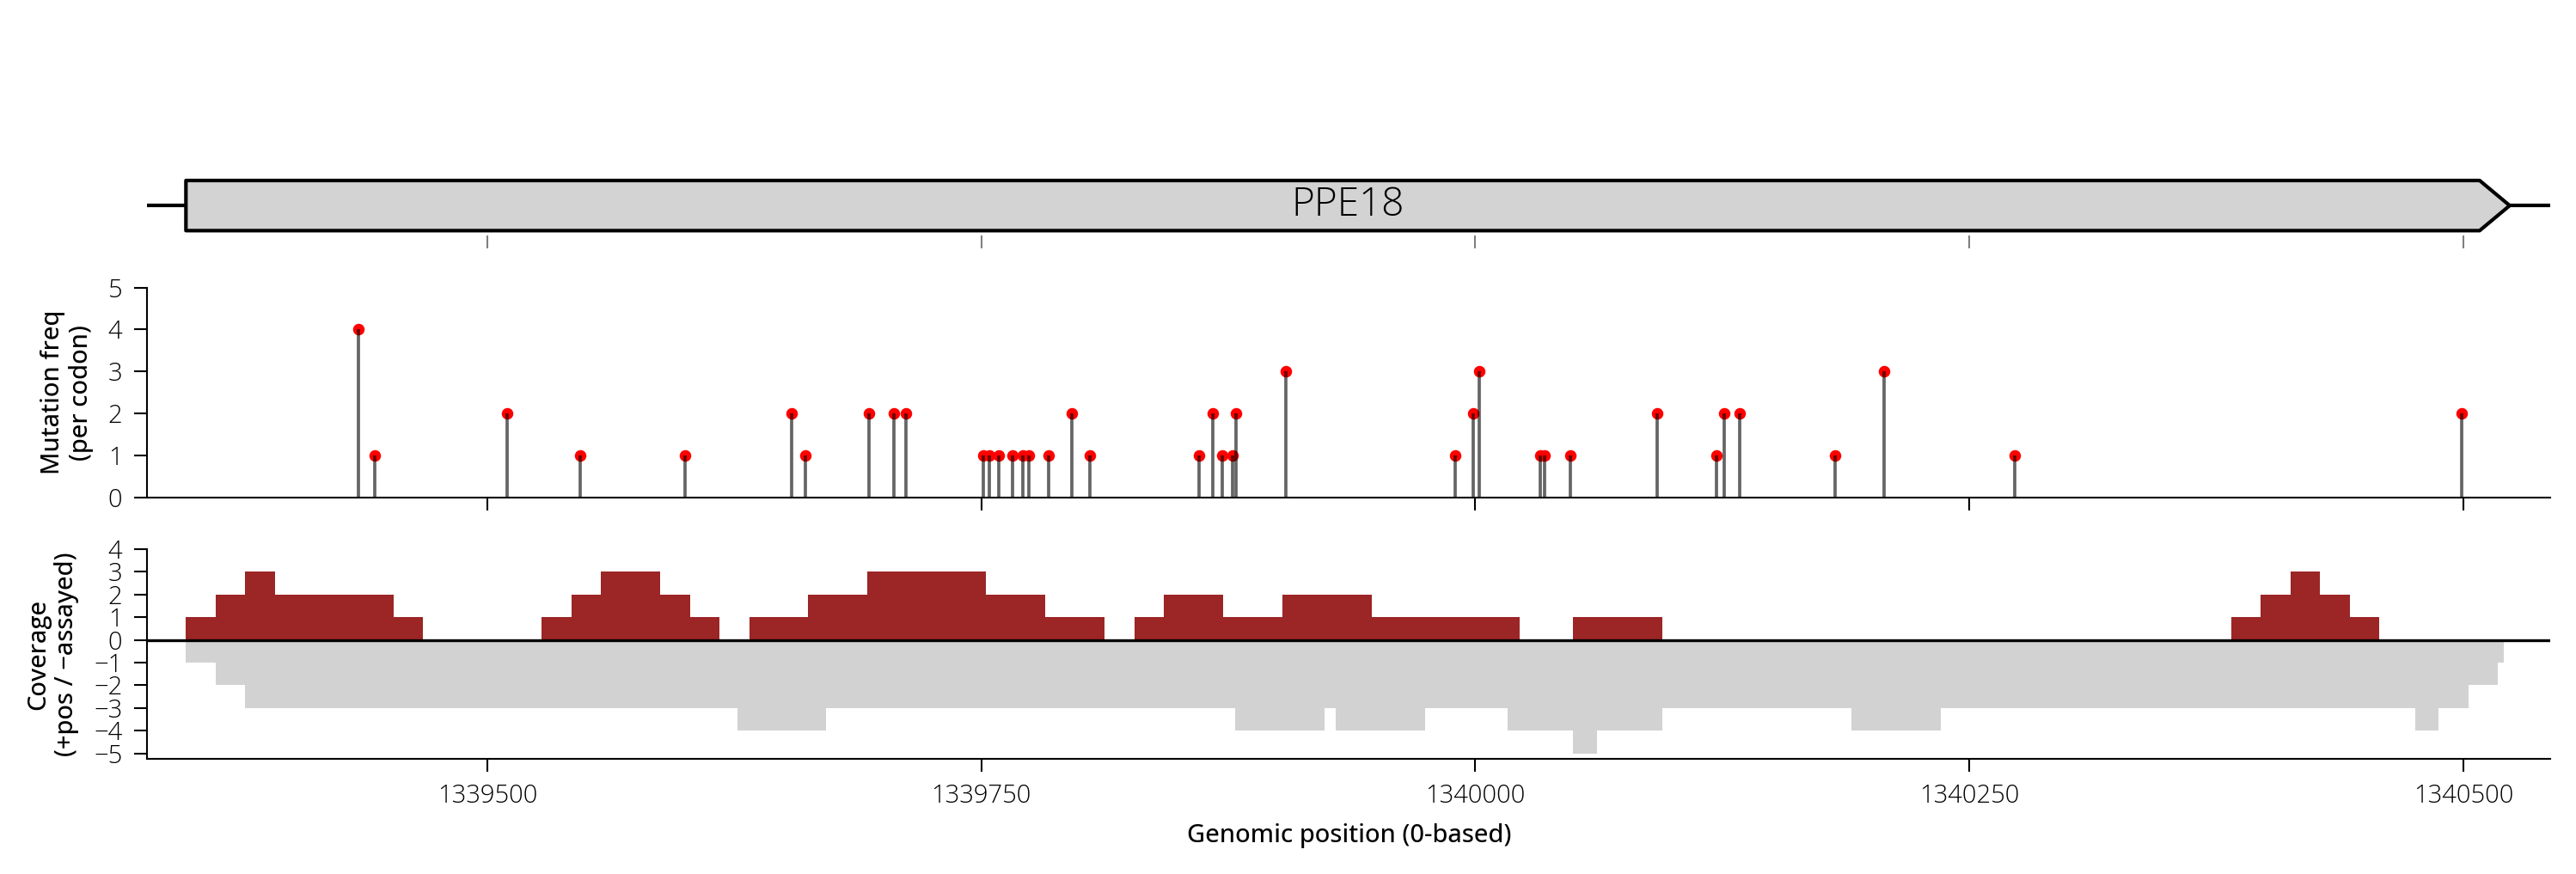

In [177]:

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

i_Symbol_List = ["PPE18"]

i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
i_Gene_End = i_Gene_MutInfo_DF["End"].max()
Viz_Start = i_Gene_Start - 20
Viz_End = i_Gene_End + 20


# ---- Make the requested plots ----
RvPerCodon_NSMutFreq_DF_VizRegion = (
    RvPerCodon_NSMutFreq_DF
        .loc[
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] >= Viz_Start) &
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] <= Viz_End)
        ]
        .copy()
)


Rv_EpitopeCov_NonZero_DF_VizRegion = (
    Rv_EpitopeCov_NonZero_DF
        .loc[
            (Rv_EpitopeCov_NonZero_DF["start"] >= Viz_Start) &
            (Rv_EpitopeCov_NonZero_DF["start"] <= Viz_End)
        ]
        .copy()
)




# Figure 1: mutfreq + diverging bars
fig1, axs = plt.subplots(
    3, 1, figsize=(10, 3.4),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 3, 3]}
)
Genome_Anno_ax, MF_ax, EpiSumm_ax = axs


Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

Graphic_Record_cropped.plot(ax=Genome_Anno_ax)

Genome_Anno_ax.set_xlabel("")
Genome_Anno_ax.set_xticklabels([])  # keep shared, labels only on bottom

Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
Genome_Anno_ax.set_xticks([])

plot_mutfreq_per_codon(MF_ax,
                       RvPerCodon_NSMutFreq_DF_VizRegion,
                       x_col = "Pos_0based", #"RvCoord_Start_0idx",
                       y_col = "Mutation_Count", #"NS_MutEvent_Freq",
                       point_size = 5,)

MF_ax.set_yticks(range(0, 6))


plot_epitope_coverage_diverging_bars(EpiSumm_ax,
                                     Rv_EpitopeCov_NonZero_DF_VizRegion,
                                     x_col="start",
                                     assayed_col="Cov_AssayedPeptides",
                                     positive_col="Cov_PosEpitopes",
                                     positive_color = "#8B0000",
                                     legend = False,
                                     )

EpiSumm_ax.set_yticks(range(-5, 5))

fig1.tight_layout()
plt.show()


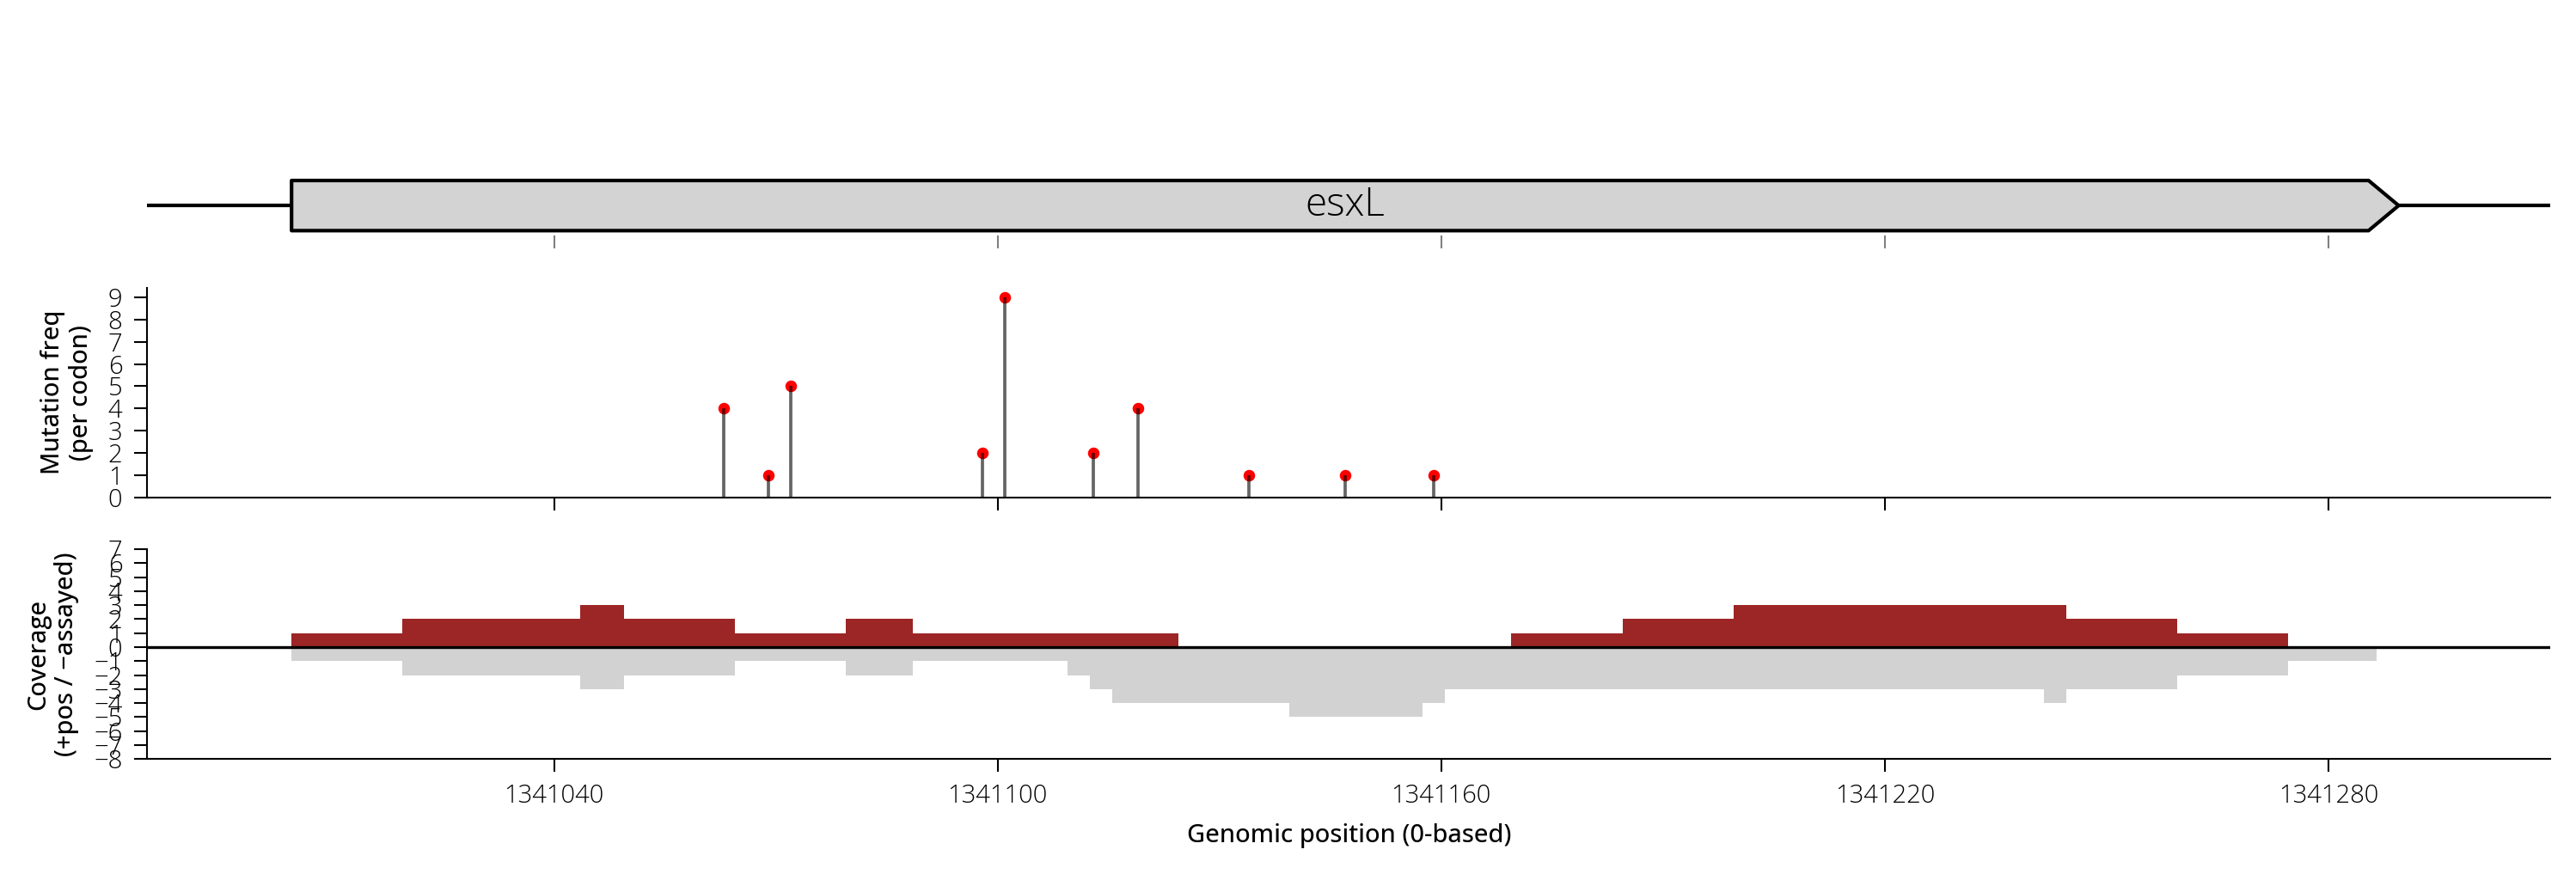

In [178]:

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

i_Symbol_List = ["esxL"]

i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
i_Gene_End = i_Gene_MutInfo_DF["End"].max()
Viz_Start = i_Gene_Start - 20
Viz_End = i_Gene_End + 20


# ---- Make the requested plots ----
RvPerCodon_NSMutFreq_DF_VizRegion = (
    RvPerCodon_NSMutFreq_DF
        .loc[
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] >= Viz_Start) &
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] <= Viz_End)
        ]
        .copy()
)


Rv_EpitopeCov_NonZero_DF_VizRegion = (
    Rv_EpitopeCov_NonZero_DF
        .loc[
            (Rv_EpitopeCov_NonZero_DF["start"] >= Viz_Start) &
            (Rv_EpitopeCov_NonZero_DF["start"] <= Viz_End)
        ]
        .copy()
)




# Figure 1: mutfreq + diverging bars
fig1, axs = plt.subplots(
    3, 1, figsize=(10, 3.4),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 3, 3]}
)
Genome_Anno_ax, MF_ax, EpiSumm_ax = axs

Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

Graphic_Record_cropped.plot(ax=Genome_Anno_ax)

Genome_Anno_ax.set_xlabel("")
Genome_Anno_ax.set_xticklabels([])  # keep shared, labels only on bottom
# Genome_Anno_ax.set_xticks([])

Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)

plot_mutfreq_per_codon(MF_ax,
                       RvPerCodon_NSMutFreq_DF_VizRegion,
                       x_col = "Pos_0based", #"RvCoord_Start_0idx",
                       y_col = "Mutation_Count", #"NS_MutEvent_Freq",
                       point_size = 5,)

MF_ax.set_yticks(range(0, 10))


plot_epitope_coverage_diverging_bars(EpiSumm_ax,
                                     Rv_EpitopeCov_NonZero_DF_VizRegion,
                                     x_col="start",
                                     assayed_col="Cov_AssayedPeptides",
                                     positive_col="Cov_PosEpitopes",
                                     positive_color = "#8B0000",
                                     legend = False,
                                     )

EpiSumm_ax.set_yticks(range(-8, 8))


fig1.tight_layout()
plt.show()


In [ ]:

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

i_Symbol_List = ["esxL"]

i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF[  Genes_GCandMutFreqStats_DF["Symbol"].isin(i_Symbol_List) ]

i_Gene_Start = i_Gene_MutInfo_DF["Start"].min()
i_Gene_End = i_Gene_MutInfo_DF["End"].max()
Viz_Start = i_Gene_Start - 20
Viz_End = i_Gene_End + 20


# ---- Make the requested plots ----
RvPerCodon_NSMutFreq_DF_VizRegion = (
    RvPerCodon_NSMutFreq_DF
        .loc[
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] >= Viz_Start) &
            (RvPerCodon_NSMutFreq_DF["Pos_0based"] <= Viz_End)
        ]
        .copy()
)

Rv_EpitopeCov_NonZero_DF_VizRegion = (
    Rv_EpitopeCov_NonZero_DF
        .loc[
            (Rv_EpitopeCov_NonZero_DF["start"] >= Viz_Start) &
            (Rv_EpitopeCov_NonZero_DF["start"] <= Viz_End)
        ]
        .copy()
)

# Figure 1: mutfreq + diverging bars
fig1, axs = plt.subplots(
    3, 1, figsize=(10, 3.4),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 3, 3]}
)
Genome_Anno_ax, MF_ax, EpiSumm_ax = axs


Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

Graphic_Record_cropped.plot(ax=Genome_Anno_ax)

Genome_Anno_ax.set_xlabel("")
Genome_Anno_ax.set_xticklabels([])  # keep shared, labels only on bottom
# Genome_Anno_ax.set_xticks([])

Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)

plot_mutfreq_per_codon(MF_ax,
                       RvPerCodon_NSMutFreq_DF_VizRegion,
                       x_col = "Pos_0based", #"RvCoord_Start_0idx",
                       y_col = "Mutation_Count", #"NS_MutEvent_Freq",
                       point_size = 5,)

MF_ax.set_yticks(range(0, 10))


plot_epitope_coverage_diverging_bars(EpiSumm_ax,
                                     Rv_EpitopeCov_NonZero_DF_VizRegion,
                                     x_col="start",
                                     assayed_col="Cov_AssayedPeptides",
                                     positive_col="Cov_PosEpitopes",
                                     positive_color = "#8B0000",
                                     legend = False,
                                     )

EpiSumm_ax.set_yticks(range(-8, 8))


fig1.tight_layout()
plt.show()


# Extras